# **NIH Deep Learning**

Dataset Link : https://huggingface.co/datasets/Sohaibsoussi/NIH-Chest-X-ray-dataset-small?library=datasets

## **Dataset Downloading**

In [1]:
import os
import shutil
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
import random
from PIL import Image
warnings.filterwarnings('ignore')

**Google Colab**

In [2]:
!pip install -q datasets

In [3]:
from datasets import load_dataset

ds = load_dataset("Sohaibsoussi/NIH-Chest-X-ray-dataset-small")

README.md:   0%|          | 0.00/988 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/438M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/435M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/437M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/435M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4326 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1730 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1279 [00:00<?, ? examples/s]

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 4326
    })
    validation: Dataset({
        features: ['image', 'labels'],
        num_rows: 1730
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 1279
    })
})

In [5]:
ds['train'].features['labels'].feature.names

['No Finding',
 'Atelectasis',
 'Cardiomegaly',
 'Effusion',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pneumonia',
 'Pneumothorax',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Fibrosis',
 'Pleural_Thickening',
 'Hernia']

#### **Dataset Split**

In [6]:
import os
from tqdm import tqdm

base_dir = "dataset"

# Create structured folders
for split in ["train", "test", "validation"]:
    for label in ds["train"].features["labels"].feature.names:
        path = os.path.join(base_dir, split, label.lower())
        os.makedirs(path, exist_ok=True)

label_names = ds["train"].features["labels"].feature.names

In [7]:
label_names

['No Finding',
 'Atelectasis',
 'Cardiomegaly',
 'Effusion',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pneumonia',
 'Pneumothorax',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Fibrosis',
 'Pleural_Thickening',
 'Hernia']

In [8]:
def save_split(split_name):
    dataset_split = ds[split_name]

    for i in tqdm(range(len(dataset_split)), desc=f"Saving {split_name}"):
        sample = dataset_split[i]

        image = sample["image"]
        label = sample["labels"]
        label_name = label_names[label[0]].lower()

        save_path = os.path.join(
            base_dir,
            split_name,
            label_name,
            f"{split_name}_{i}.jpg"
        )

        if image.mode == 'RGBA':
            image = image.convert('RGB')

        image.save(save_path)

# Save all splits
save_split("train")
save_split("validation")
save_split("test")

print("All images saved in structured format.")

Saving test: 100%|██████████| 1279/1279 [00:18<00:00, 68.79it/s]

All images saved in structured format.


**Train Dataset**

In [9]:
train_dir = "dataset/train"

list_of_directories = os.listdir(train_dir)
counts = []

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    counts.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

hernia has 7 images
no finding has 2489 images
effusion has 271 images
emphysema has 49 images
infiltration has 433 images
nodule has 126 images
mass has 99 images
pneumonia has 7 images
pneumothorax has 69 images
consolidation has 125 images
atelectasis has 431 images
pleural_thickening has 40 images
cardiomegaly has 65 images
fibrosis has 64 images
edema has 51 images


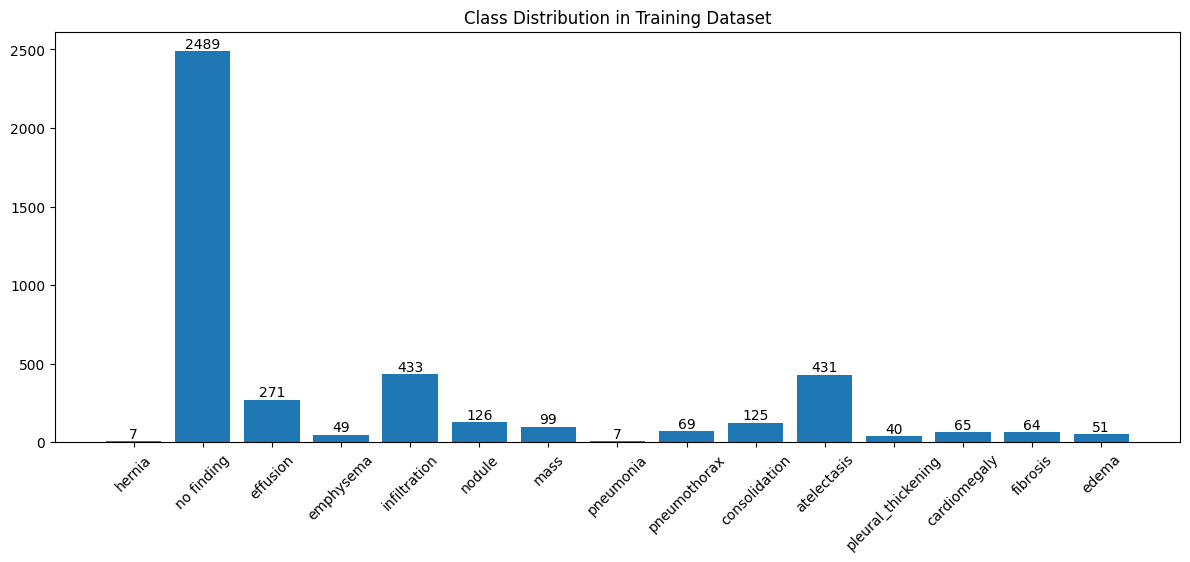

In [10]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories, counts)

plt.xticks(rotation=90)
plt.title("Class Distribution in Training Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

**Validation Dataset**

In [11]:
val_dir = "dataset/validation"

list_of_directories_valid = os.listdir(val_dir)
valid_count_images = []

for dir in list_of_directories_valid:
    dir_path = os.path.join(val_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    valid_count_images.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

hernia has 1 images
no finding has 995 images
effusion has 100 images
emphysema has 16 images
infiltration has 186 images
nodule has 50 images
mass has 35 images
pneumonia has 4 images
pneumothorax has 27 images
consolidation has 48 images
atelectasis has 177 images
pleural_thickening has 21 images
cardiomegaly has 26 images
fibrosis has 29 images
edema has 15 images


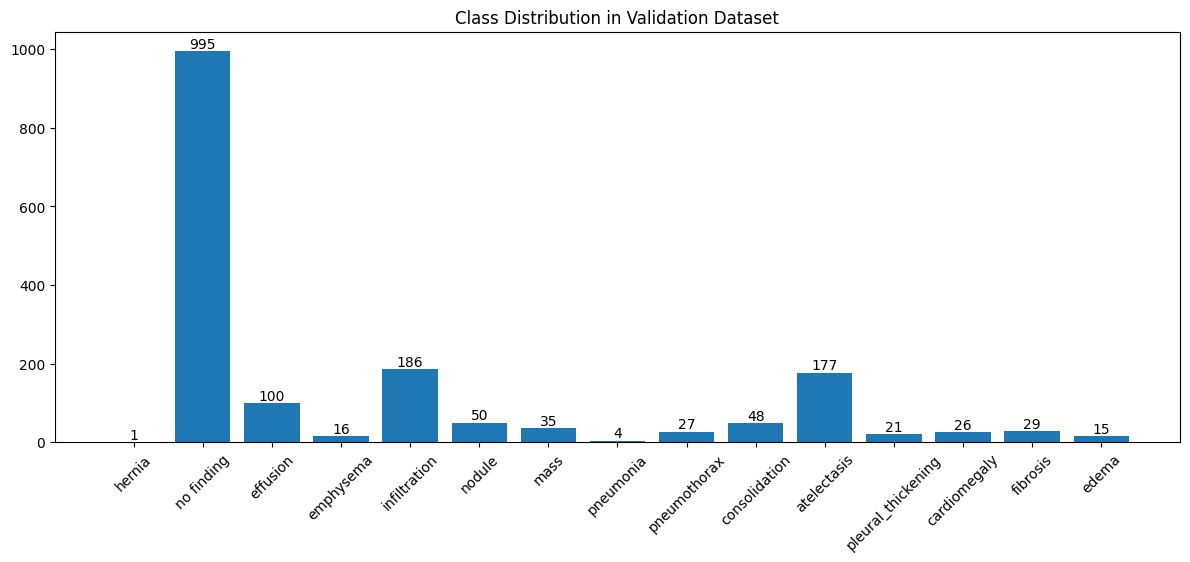

In [12]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories_valid, valid_count_images)

plt.xticks(rotation=90)
plt.title("Class Distribution in Validation Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

**Test Dataset**

In [13]:
test_dir = "dataset/test"

list_of_directories_test = os.listdir(test_dir)
test_count_images = []

for dir in list_of_directories_test:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    test_count_images.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

hernia has 1 images
no finding has 541 images
effusion has 114 images
emphysema has 44 images
infiltration has 158 images
nodule has 29 images
mass has 31 images
pneumonia has 3 images
pneumothorax has 54 images
consolidation has 51 images
atelectasis has 160 images
pleural_thickening has 15 images
cardiomegaly has 30 images
fibrosis has 22 images
edema has 26 images


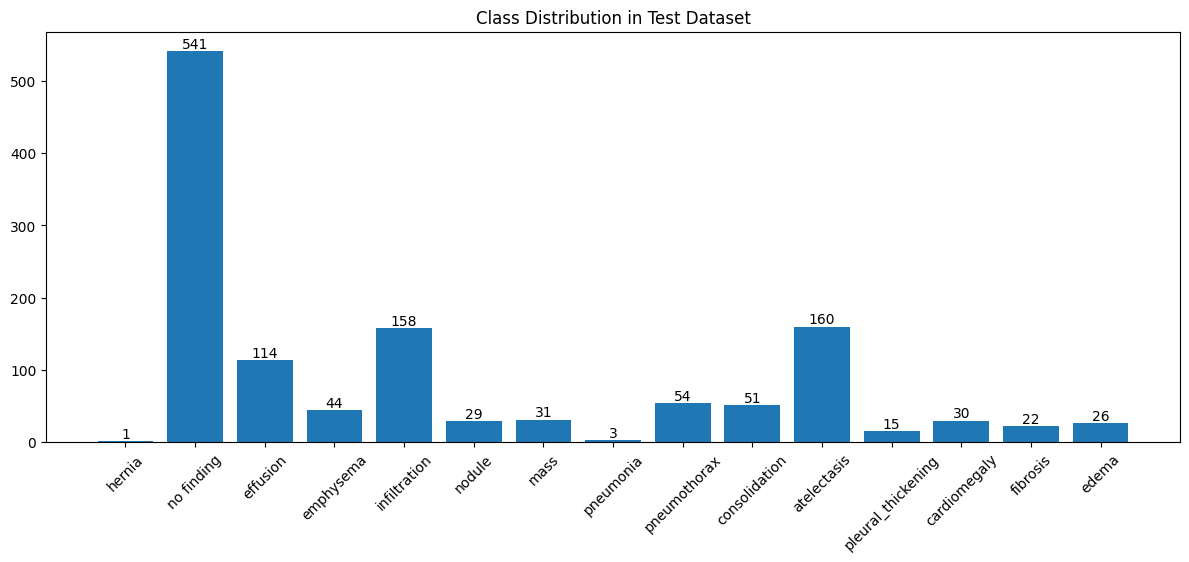

In [14]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories_test, test_count_images)

plt.xticks(rotation=90)
plt.title("Class Distribution in Test Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

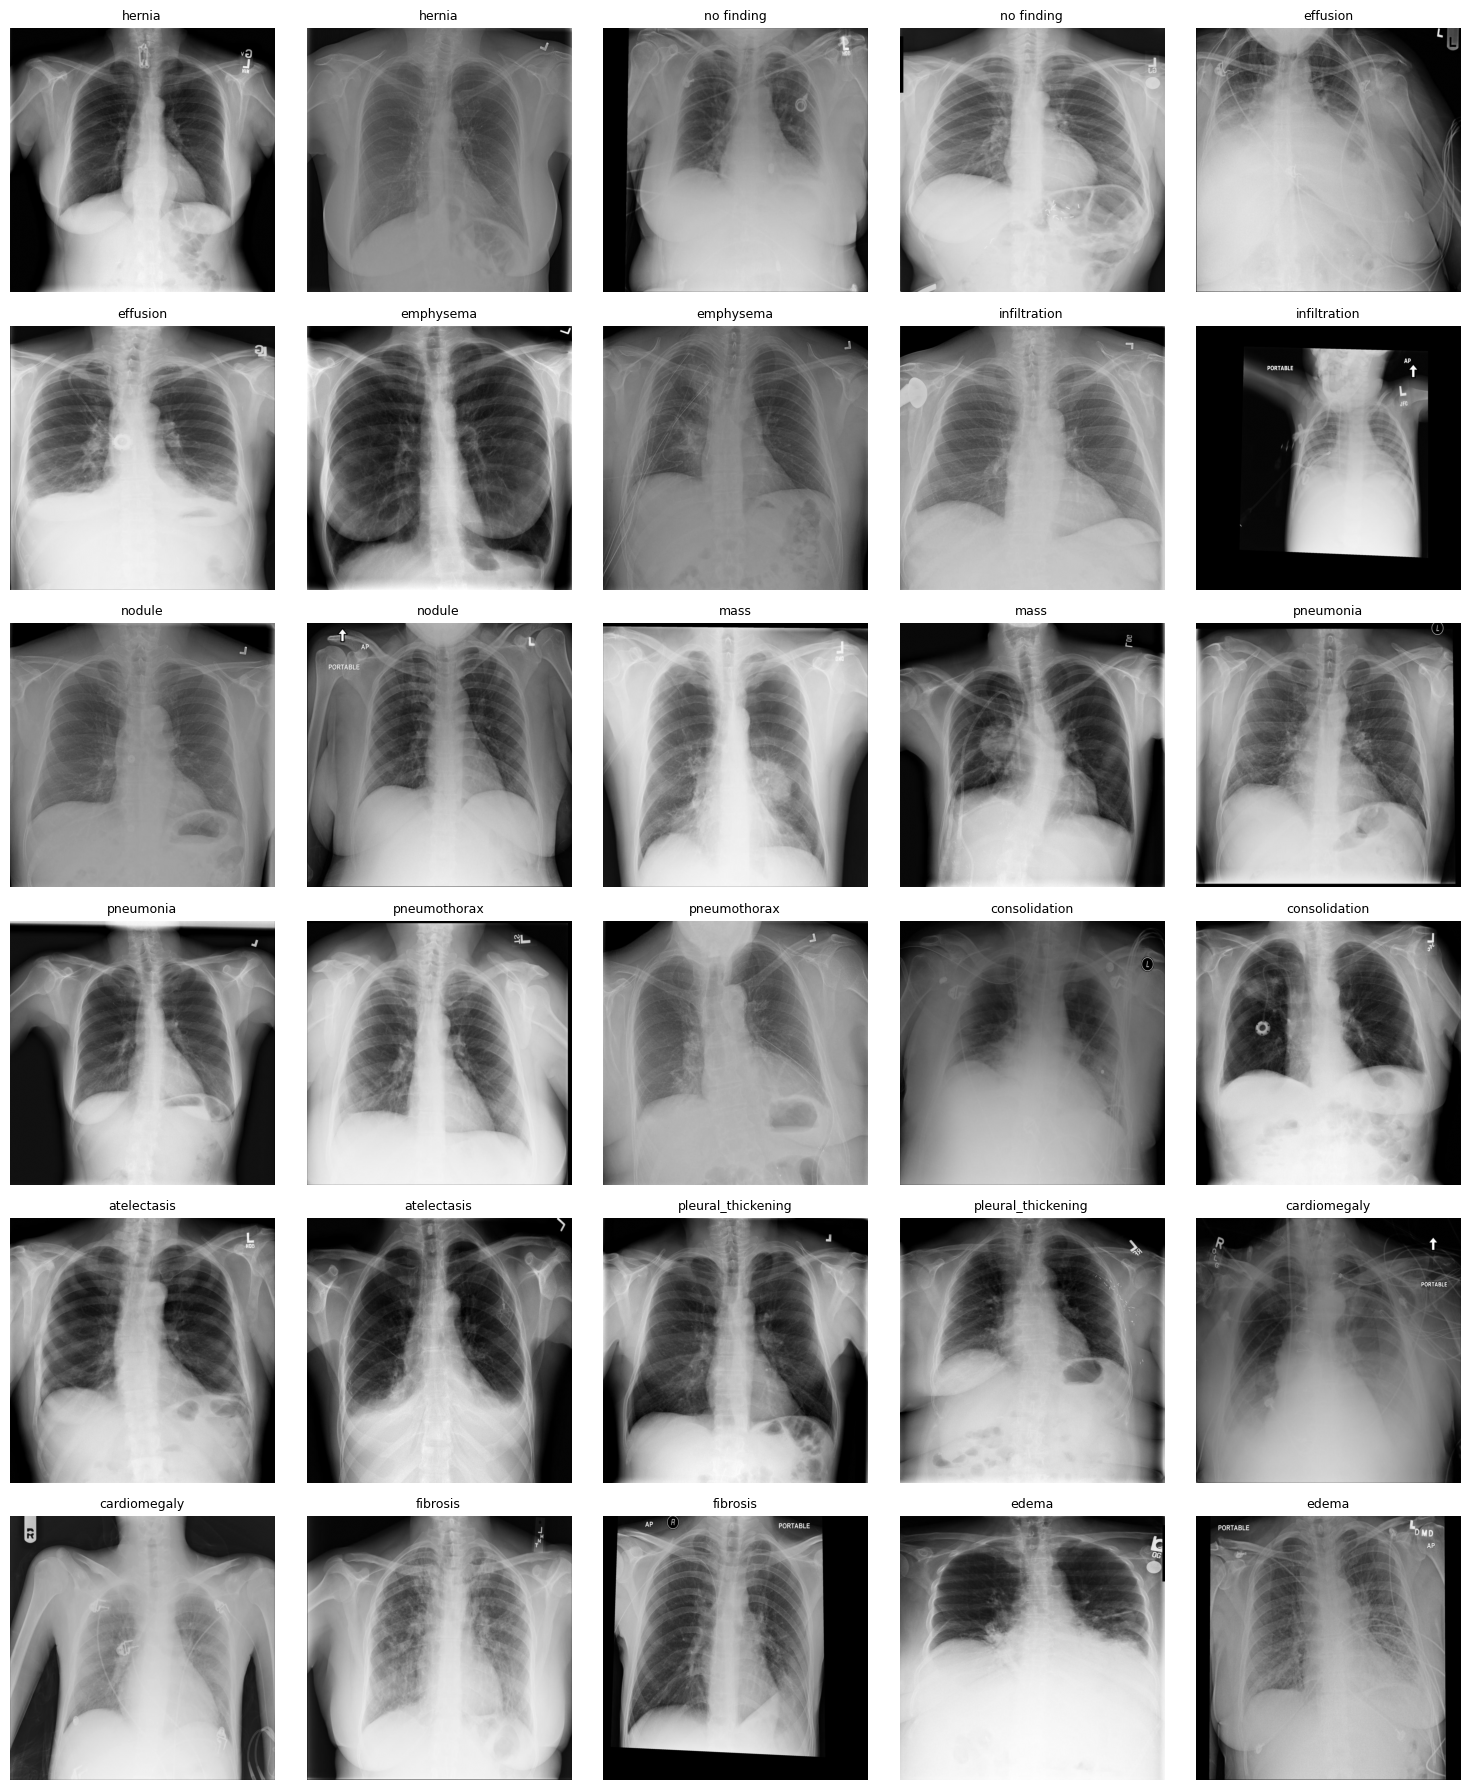

In [15]:
classes = os.listdir(os.path.join(base_dir, "train"))

images_per_class = 2
total_images_to_display = len(classes) * images_per_class

plot_cols = 5
plot_rows = math.ceil(total_images_to_display / plot_cols)

plt.figure(figsize=(15, 3 * plot_rows))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(os.path.join(base_dir, "train"), class_name)

    available_images = os.listdir(class_path)

    num_to_sample = min(images_per_class, len(available_images))

    if num_to_sample > 0:
        sampled_images = random.sample(available_images, num_to_sample)

        for img_name in sampled_images:
            if plot_index > plot_rows * plot_cols:
                break

            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            plt.subplot(plot_rows, plot_cols, plot_index)
            plt.imshow(img, cmap='gray')
            plt.title(class_name, fontsize=9)
            plt.axis("off")

            plot_index += 1
    if plot_index > plot_rows * plot_cols:
        break

plt.tight_layout()
plt.show()

## **Data Augmentation**

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_dir = "dataset/train"
val_dir = "dataset/validation"
test_dir = "dataset/test"

In [18]:
img_size = (224, 224)
batch_size = 32

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4326 images belonging to 15 classes.


In [20]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1730 images belonging to 15 classes.
Found 1279 images belonging to 15 classes.


## **Class Imbalance Check**

In [21]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'atelectasis': 0, 'cardiomegaly': 1, 'consolidation': 2, 'edema': 3, 'effusion': 4, 'emphysema': 5, 'fibrosis': 6, 'hernia': 7, 'infiltration': 8, 'mass': 9, 'no finding': 10, 'nodule': 11, 'pleural_thickening': 12, 'pneumonia': 13, 'pneumothorax': 14}

Imbalance Ratio: 355.57


In [22]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(0.6691415313225058), 1: np.float64(4.436923076923077), 2: np.float64(2.3072), 3: np.float64(5.654901960784314), 4: np.float64(1.0642066420664207), 5: np.float64(5.885714285714286), 6: np.float64(4.50625), 7: np.float64(41.2), 8: np.float64(0.6660508083140878), 9: np.float64(2.9131313131313132), 10: np.float64(0.11586982723985537), 11: np.float64(2.2888888888888888), 12: np.float64(7.21), 13: np.float64(41.2), 14: np.float64(4.179710144927537)}


## **Base Model**

In [23]:
def evaluate_model(model, name, generator):
    print(f"\nEvaluating {name}...")
    results = model.evaluate(generator, verbose=0)
    metrics = {
        'Model': name,
        'Loss': results[0],
        'Accuracy': results[1],
        'Precision': results[2],
        'Recall': results[3],
        'F1-Score': results[4]
    }
    return metrics

In [24]:
class_len = train_generator.num_classes
epochs = 10
model_metrics = []

In [25]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.applications import VGG19, MobileNetV2, ResNet101, DenseNet201

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

#### **Base Model**

In [27]:
base_model = Sequential([
    Input(shape=(224, 224, 3)),

    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [28]:
base_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [29]:
base_model_history = base_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 141s 802ms/step - accuracy: 0.0677 - f1_score: 0.0423 - loss: 3.7358 - precision: 0.0747 - recall: 0.0180 - val_accuracy: 0.0497 - val_f1_score: 0.0114 - val_loss: 5.1004 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 613ms/step - accuracy: 0.0580 - f1_score: 0.0389 - loss: 3.6068 - precision: 0.0537 - recall: 0.0118 - val_accuracy: 5.7803e-04 - val_f1_score: 7.7027e-05 - val_loss: 5.4126 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 609ms/step - accuracy: 0.0682 - f1_score: 0.0471 - loss: 3.4379 - precision: 0.0577 - recall: 0.0123 - val_accuracy: 0.0069 - val_f1_score: 0.0029 - val_loss: 3.3672 - val_precision: 0.0294 - val_recall: 5.7803e-04
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 607ms/step - accuracy: 0.0643 - f1_score: 0.0422 - loss: 3.4298 - precision: 0.0522 - recall: 0.0095 - val_accuracy: 0.0127 - val_f1_score: 0.0058 - val_loss: 3.5

In [30]:
base_model_metrics = evaluate_model(base_model, 'Base Model', test_generator)

base_model_metrics


Evaluating Base Model...


{'Model': 'Base Model',
 'Loss': 2.970207691192627,
 'Accuracy': 0.03596559911966324,
 'Precision': 0.00699300691485405,
 'Recall': 0.0007818608428351581,
 'F1-Score': 0.031656619161367416}